<a href="https://colab.research.google.com/github/Jashed-20/mnist_cnn_project/blob/main/mnist_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist
from sklearn.metrics import confusion_matrix
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [30]:
(X_train,Y_train),(X_test,Y_test)=mnist.load_data()

In [31]:
type(X_train)

numpy.ndarray

In [32]:
print(X_train.shape,Y_train.shape,X_test.shape,Y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [33]:
#printing the 10th image
print(X_train[9])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0 189 190   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0 143 247 153   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 136 247 242  86   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 192 252 187   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  62 185  18   

In [34]:
print(X_train[9].shape)

(28, 28)


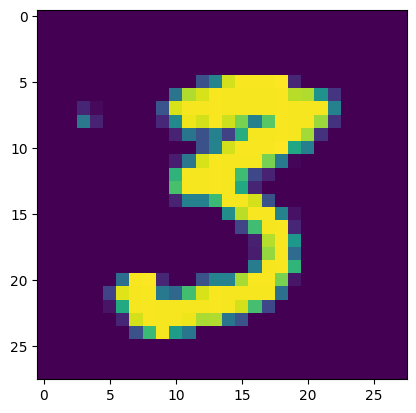

3


In [35]:
plt.imshow(X_train[49])
plt.show()

print(Y_train[49])

In [36]:
print(Y_train.shape,Y_test.shape)

(60000,) (10000,)


In [37]:
print(np.unique(Y_train))
print(np.unique(Y_test))


[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


In [38]:
X_train=X_train/255
X_test=X_test/255


In [39]:
print(X_train[9])


[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

In [40]:
model = keras.Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(64, activation='relu'),

    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
#compiling the neural network
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [42]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=10
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.9568 - loss: 0.1363 - val_accuracy: 0.9869 - val_loss: 0.0404
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9865 - loss: 0.0429 - val_accuracy: 0.9871 - val_loss: 0.0398
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9905 - loss: 0.0298 - val_accuracy: 0.9886 - val_loss: 0.0378
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9901 - val_loss: 0.0334
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 0.9914 - val_loss: 0.0332
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9955 - loss: 0.0160 - val_accuracy: 0.9908 - val_loss: 0.0319
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9956 - loss: 0.0143 - val_accuracy: 0.9912 - val_loss: 0.0301
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9960 - loss: 0.0126 -

In [43]:
loss,accuracy=model.evaluate(X_test,Y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0477


<function matplotlib.pyplot.show(close=None, block=None)>

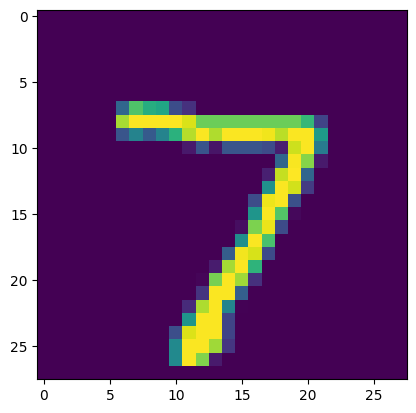

In [44]:
plt.imshow(X_test[0])
plt.show

In [45]:
print(Y_test[0])

7


In [46]:
Y_pred=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [47]:
print(Y_pred.shape)

(10000, 10)


In [48]:
print(Y_pred[0])

[3.2420430e-10 5.2531720e-07 8.2343981e-08 5.1012137e-08 3.4180129e-04
 1.5271929e-08 2.7187547e-11 9.9965703e-01 5.4917529e-11 4.6550250e-07]


In [49]:
#converting the prediction probabilities to class label
label_for_first_test_image=np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [50]:
Y_pred_labels=[np.argmax(i) for i in Y_pred]


In [51]:
conf_mat=confusion_matrix(Y_test,Y_pred_labels)
print(conf_mat)

[[ 974    0    1    1    0    0    2    0    2    0]
 [   0 1134    0    0    0    0    0    0    1    0]
 [   0    1 1028    0    0    0    0    1    2    0]
 [   0    0    2 1006    0    2    0    0    0    0]
 [   0    0    1    0  976    0    2    0    2    1]
 [   0    0    0    7    0  884    1    0    0    0]
 [   3    1    0    0    1    4  948    0    1    0]
 [   0    3    6    0    0    0    0 1016    1    2]
 [   0    0    1    1    0    1    0    0  970    1]
 [   0    0    0    4   23   20    0    1    5  956]]


Text(0.5, 47.7222222222222, 'predicted labels')

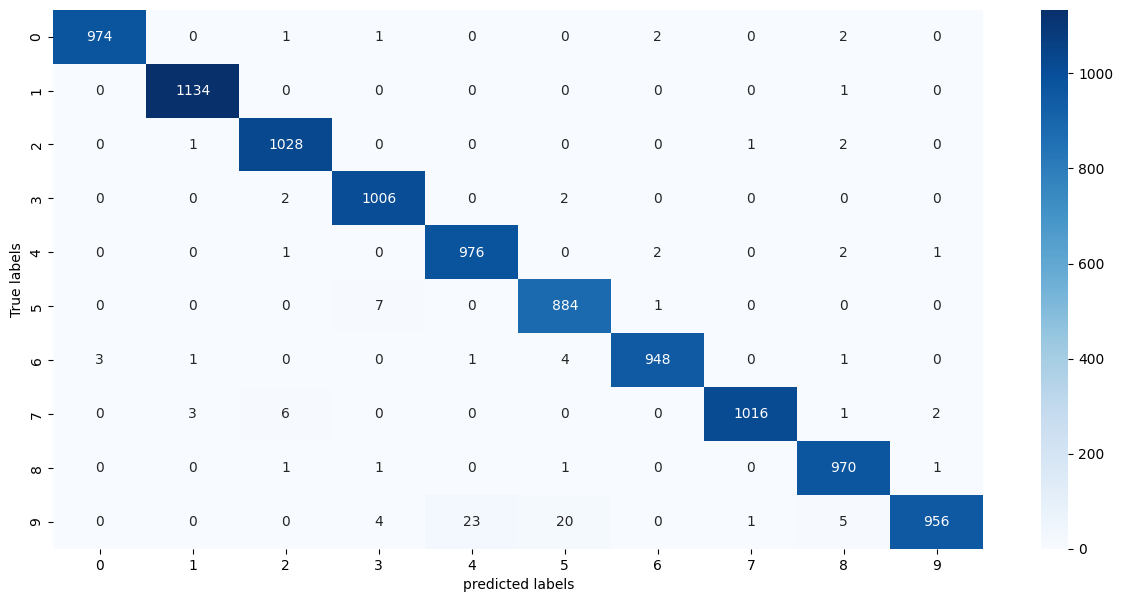

In [52]:
plt.figure(figsize=(15,7))
sns.heatmap(conf_mat,annot=True,fmt='d',cmap='Blues')
plt.ylabel('True labels')
plt.xlabel('predicted labels')


In [53]:
input_image_path='/content/mnist-project-thumb.png'
input_image=cv2.imread(input_image_path)

In [54]:
type(input_image)

numpy.ndarray

In [55]:
print(input_image)

[[[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 ...

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]
  ...
  [ 0  0  0]
  [ 0  0  0]
  [ 0  0  0]]

 [[19 19 19]
  [19 19 19]
  [51 51 51]
  ...
  [51 51 51]
  [51 51 51]
  [19 19 19]]]


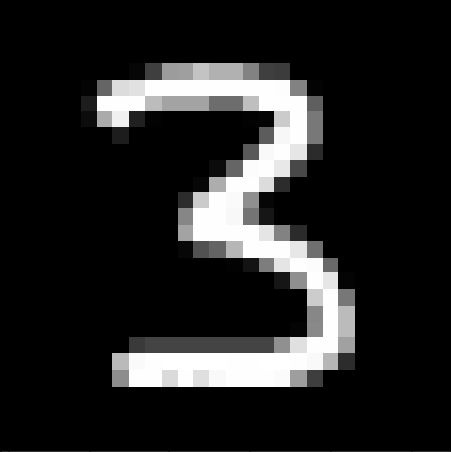

In [56]:
cv2_imshow(input_image)

In [57]:
input_image.shape


(452, 451, 3)

In [58]:
grayscale=cv2.cvtColor(input_image,cv2.COLOR_RGB2GRAY)

In [59]:
grayscale.shape

(452, 451)

In [60]:
input_image_resize=cv2.resize(grayscale,(28,28))

In [61]:
input_image_resize.shape

(28, 28)

In [62]:
cv2_imshow(input_image_resize)


In [63]:
input_image_resize=input_image_resize/255

In [64]:
image_reshaped=np.reshape(input_image_resize,[1,28,28])

In [65]:
input_prediction=model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 519ms/step
[[2.0896607e-33 1.0778605e-22 1.0020361e-21 1.0000000e+00 8.7543200e-24
  1.7654195e-18 1.1958132e-28 5.3915727e-23 1.1995678e-22 1.2881105e-25]]


In [66]:
image_pred_final=np.argmax(input_prediction)


In [67]:
print(image_pred_final)

3
